# 03 - KMeans Clustering

This notebook loads the full scaled 10,000-row preprocessing output, reduces it with PCA, uses the elbow method to choose the number of clusters, fits KMeans in a 10-component PCA space, visualizes clusters with 2-component PCA and t-SNE, and profiles the resulting groups.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

BASE_DIR = Path('..').resolve()
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PLOTS_DIR = BASE_DIR / 'plots' / 'clustering'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

X_scaled = pd.read_csv(PROCESSED_DIR / 'X_scaled.csv')
source_df = pd.read_csv(PROCESSED_DIR / 'preprocessed_sample.csv')
print('Loaded X_scaled shape:', X_scaled.shape)
print('Loaded source data shape:', source_df.shape)
X_scaled.head()

Loaded X_scaled shape: (10000, 34)
Loaded source data shape: (10000, 36)


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,0.128691,-0.232885,1.335064,0.636316,-0.395886,0.779695,-0.128278,0.358216,1.216114,0.979899,-1.093881,-1.093512,-1.691003,-0.030484,-0.001900,0.009703,0.930341,-0.230621,-0.647267,-0.331664,-0.192915,0.479119,-0.556075,-0.071592,-1.067665,-1.079924,1.359041,0.063761,0.912623,-0.807100,0.366175,-0.387063,-0.387905,-1.104205
1,-1.382696,-0.405070,2.460555,-1.262202,-0.395886,0.779695,-0.571194,-1.129942,0.242483,-0.337878,0.344206,-1.093512,-0.160983,0.023899,-0.595752,3.073785,-0.843103,-0.230621,-0.647267,-0.331664,1.249362,-0.354795,0.073157,1.750365,-0.603821,-0.428122,2.461799,0.248691,0.912623,-0.572080,0.659651,0.775598,-1.066300,-1.268498
2,-0.219797,0.369764,0.495098,-1.781796,-0.395886,0.779695,0.226056,0.625027,-0.244333,2.297676,-1.093881,0.464974,-0.014139,1.447507,0.591952,0.009703,-0.479924,-0.230621,0.877688,-0.331664,-0.604994,1.193903,0.289187,0.086284,-0.137256,0.893660,0.510579,-0.014878,-1.821964,-0.609322,1.328690,2.508818,0.735909,-0.406216
3,-1.544470,0.111486,0.001397,-2.711071,-0.395886,1.487865,0.226056,-0.205934,-1.704780,-0.337878,1.063250,1.244218,-0.170457,-0.183738,-1.189605,0.009703,-0.618006,-0.230621,-0.647267,-0.331664,-0.192915,-0.116534,0.241752,-0.097108,-1.121775,0.340609,0.011885,1.304600,0.001094,-0.893880,1.210188,1.021466,2.402500,0.594231
4,0.685719,-0.060700,0.124845,-0.422857,-0.395886,1.487865,0.137472,0.619594,-0.244333,-1.655655,-1.093881,1.244218,0.416919,-0.438061,1.779656,0.009703,-0.621125,-0.230621,-0.647267,-0.331664,-1.017073,-1.426970,1.374484,0.483367,-0.172747,-0.556615,0.136581,0.323949,-0.910435,-0.052051,0.352737,0.300488,0.386435,-0.257973


## PCA and elbow method
PCA reduces the feature space for KMeans fitting to 10 components, while 2 components are kept only for visualization. The elbow method helps choose a suitable number of clusters.

Explained variance ratio (10 components): [0.10095211 0.07339598 0.06034281 0.05812073 0.04836396 0.03204673
 0.03169396 0.03126939 0.03097233 0.03060036]
Cumulative explained variance (10 components): 0.4978


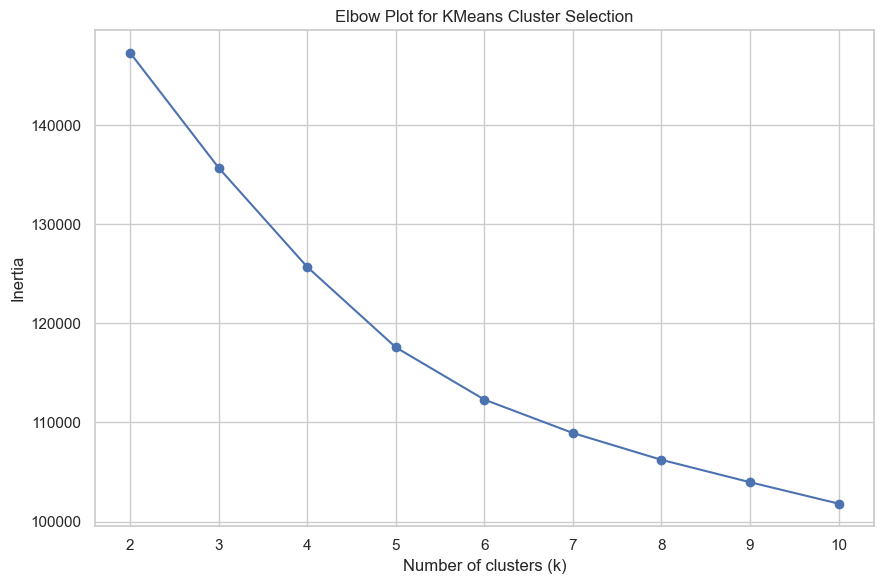

Estimated elbow k: 5


In [2]:
pca_fit = PCA(n_components=10, random_state=42)
X_pca_fit = pca_fit.fit_transform(X_scaled)
print('Explained variance ratio (10 components):', pca_fit.explained_variance_ratio_)
print('Cumulative explained variance (10 components):', round(pca_fit.explained_variation_ratio_.sum(), 4) if hasattr(pca_fit, 'explained_variation_ratio_') else round(pca_fit.explained_variance_ratio_.sum(), 4))

pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca_vis, columns=['PC1', 'PC2'])

k_values = list(range(2, 11))
inertias = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    model.fit(X_pca_fit)
    inertias.append(model.inertia_)

plt.figure(figsize=(9, 6))
plt.plot(k_values, inertias, marker='o')
plt.xticks(k_values)
plt.title('Elbow Plot for KMeans Cluster Selection')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'elbow_plot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


def estimate_elbow(x_values, y_values):
    x_arr = np.array(x_values, dtype=float)
    y_arr = np.array(y_values, dtype=float)
    start = np.array([x_arr[0], y_arr[0]])
    end = np.array([x_arr[-1], y_arr[-1]])
    line = end - start
    line_norm = np.linalg.norm(line)
    if line_norm == 0:
        return int(x_arr[len(x_arr) // 2])
    distances_to_line = np.abs((line[1] * x_arr - line[0] * y_arr + end[0] * start[1] - end[1] * start[0]) / line_norm)
    elbow_index = int(np.argmax(distances_to_line))
    return int(x_arr[elbow_index])

optimal_k = estimate_elbow(k_values, inertias)
if optimal_k < 2:
    optimal_k = 2
print('Estimated elbow k:', optimal_k)

## KMeans clustering
KMeans is fitted on the 10-component PCA space using the elbow-selected `k`. Cluster counts are reported and the 2D PCA and t-SNE plots use the resulting labels.

Cluster counts:
0    1632
1    2413
2    1773
3    2746
4    1436
Name: count, dtype: int64


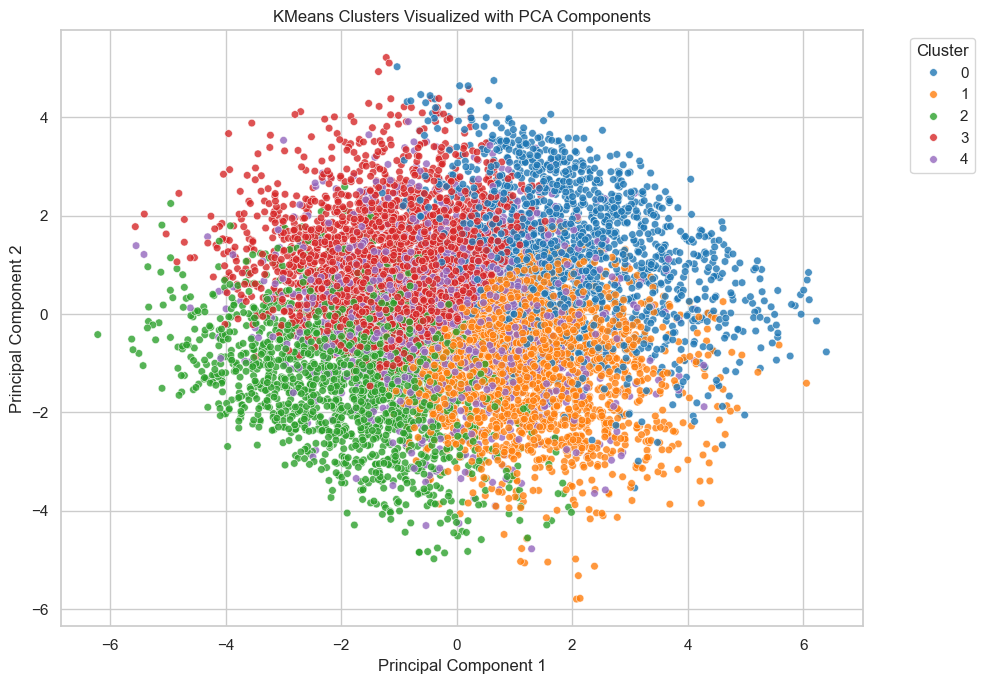

In [3]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_pca_fit)
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print('Cluster counts:')
print(cluster_counts)

pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=30, alpha=0.8)
plt.title('KMeans Clusters Visualized with PCA Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## t-SNE visualization and silhouette score
t-SNE offers a second look at cluster separation. Silhouette score is computed after excluding noise points.

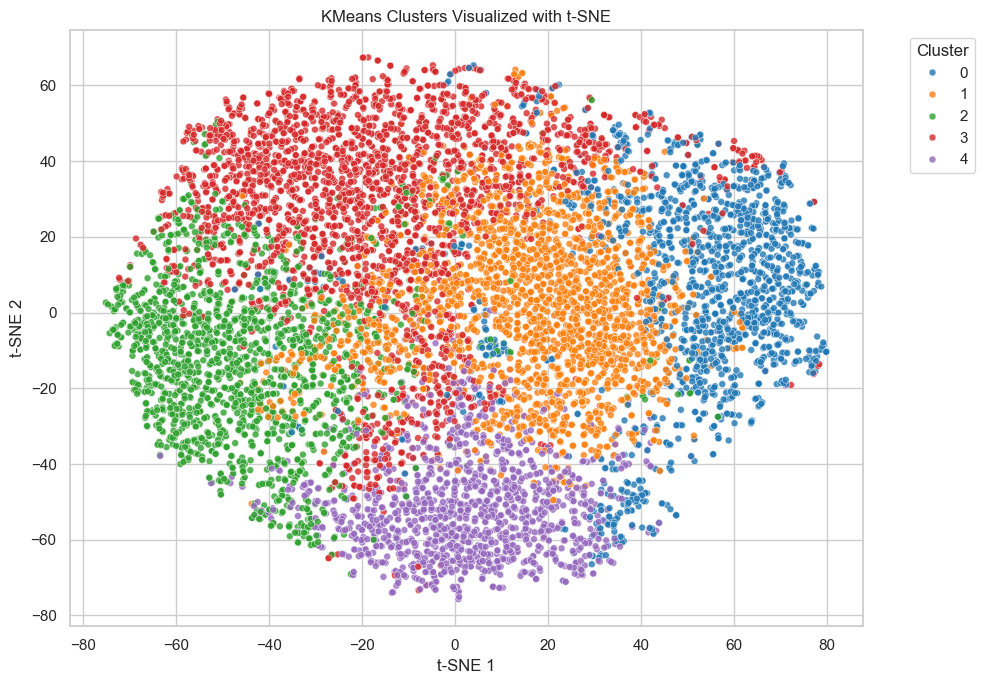

Silhouette Score: 0.1104


In [4]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_pca_fit)
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10', s=25, alpha=0.8)
plt.title('KMeans Clusters Visualized with t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'tsne_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

score = silhouette_score(X_pca_fit, cluster_labels)
print('Silhouette Score:', round(score, 4))

    silhouette  davies_bouldin  calinski_harabasz
k                                                
2       0.1198          2.5184          1490.2731
3       0.1210          2.2360          1236.1647
4       0.1132          2.1544          1154.6598
5       0.1104          2.0349          1097.8483
6       0.1000          2.0510          1013.2336
7       0.0971          2.0817           921.9337
8       0.0925          2.1395           846.5965
9       0.0878          2.1677           783.8915
10      0.0864          2.2218           735.0598
Best k by silhouette: 3 | by Davies–Bouldin: 5 | by Calinski–Harabasz: 2


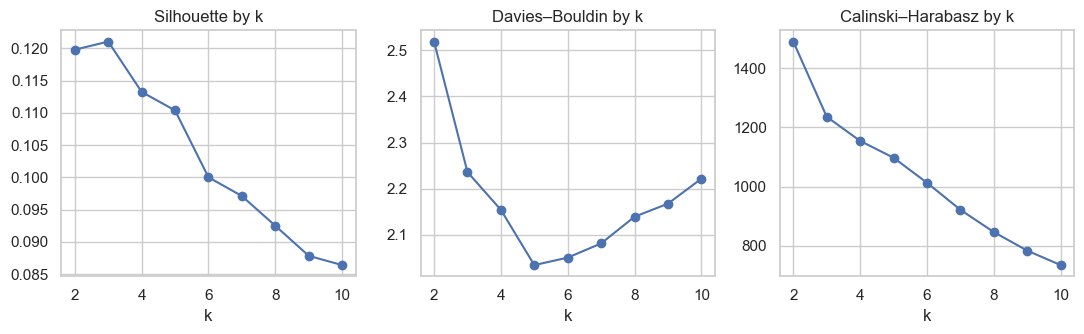

In [5]:
# Compare clustering metrics across k (2..10)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import matplotlib.pyplot as plt

ks = list(range(2, 11))
results = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca_fit)
    sil = silhouette_score(X_pca_fit, labels)
    db = davies_bouldin_score(X_pca_fit, labels)
    ch = calinski_harabasz_score(X_pca_fit, labels)
    results.append({'k': k, 'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch})

metrics_df = pd.DataFrame(results).set_index('k')
print(metrics_df.round(4))

best_sil = metrics_df['silhouette'].idxmax()
best_db = metrics_df['davies_bouldin'].idxmin()
best_ch = metrics_df['calinski_harabasz'].idxmax()
print(f'Best k by silhouette: {best_sil} | by Davies–Bouldin: {best_db} | by Calinski–Harabasz: {best_ch}')

plt.figure(figsize=(11, 3.5))
plt.subplot(1, 3, 1)
plt.plot(metrics_df.index, metrics_df['silhouette'], '-o')
plt.title('Silhouette by k')
plt.xlabel('k')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(metrics_df.index, metrics_df['davies_bouldin'], '-o')
plt.title('Davies–Bouldin by k')
plt.xlabel('k')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(metrics_df.index, metrics_df['calinski_harabasz'], '-o')
plt.title('Calinski–Harabasz by k')
plt.xlabel('k')
plt.grid(True)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'metrics_by_k.png', dpi=300, bbox_inches='tight')
plt.show()

## Cluster profiling and export
Each cluster is summarized by mean feature values, then the cluster labels are merged back into the dataset and exported.

In [6]:
profile_df = source_df.copy()
profile_df['Cluster'] = cluster_labels
print('Cluster profile means:')
display(profile_df.groupby('Cluster').mean(numeric_only=True))

profile_df.to_csv(PROCESSED_DIR / 'clustered_data.csv', index=False)
print('Clustered data saved to', PROCESSED_DIR / 'clustered_data.csv')
print('Clustering complete. Summary rows:', profile_df.shape[0])

Cluster profile means:


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,4983.801471,37.396140,38800.671645,554.977941,0.201593,1.914828,15.157475,40349.168122,44.764706,1.258578,1.507966,1.408701,479.098039,0.279184,3.065564,0.985907,0.274056,0.058211,1.877451,0.098039,23.911152,14.566176,4242.876838,1520.602941,69858.407475,32878.163680,3214.022365,0.803491,5.109681,44496.765472,0.257499,0.258716,1568.259105,0.735280,0.003676,54.514093
1,4980.859511,32.549109,46427.357750,537.358268,0.218400,1.886863,10.474513,20729.832729,70.587650,1.289681,1.607957,1.360547,426.201409,0.290260,3.030667,0.999586,0.290680,0.046830,1.897638,0.108579,23.768338,15.277248,4193.468711,1489.055533,60401.963531,31205.157843,3852.192628,0.803056,4.998550,36891.940738,0.265882,0.268338,630.347415,0.335980,0.065064,54.323912
2,4855.877045,44.675691,110596.854836,586.863508,0.263959,1.852792,22.302876,24351.219966,54.544839,1.256627,1.482234,1.454597,433.400451,0.278265,2.935702,1.016356,0.279939,0.052453,1.807107,0.100395,23.991540,14.705020,4279.596729,1505.640158,71572.828539,31045.962845,9136.621540,0.799217,4.934574,47333.363367,0.231584,0.230656,831.598676,0.140956,0.688663,44.413311
3,5109.366715,44.192280,45245.177349,602.071012,0.215586,1.903496,21.833940,18948.962491,45.002185,1.245084,1.502185,1.381282,449.050983,0.288291,2.970503,0.980335,0.283755,0.047706,1.822287,0.091042,24.029497,15.022578,4125.675164,1508.378369,55645.391479,34265.719729,3756.475601,0.803905,4.962855,30972.671522,0.210418,0.207042,698.559767,0.362979,0.191551,51.428915
4,5015.899025,39.635794,52235.060063,574.810585,0.213092,1.949861,17.388579,22403.229631,53.314763,1.219359,1.475627,1.447772,444.306407,0.290044,3.032033,0.967967,0.281881,0.050836,1.837047,0.098189,24.000696,15.196379,4206.011142,1547.108635,214570.763231,25591.775505,4331.351708,0.802236,5.012883,182679.125174,0.234518,0.234496,778.811983,0.355425,0.372563,46.120195


Clustered data saved to D:\Financial-Risk-Classification-and-Behavioral-Pattern-Clustering\data\processed\clustered_data.csv
Clustering complete. Summary rows: 10000


## Cluster Naming and Interpretation

Clusters are named based on key financial risk indicators: credit profile, debt burden, income stability, and asset position. These factors determine creditworthiness and default risk.

In [7]:
# Identify top differentiating features (highest variance across clusters)
cluster_variance = profile_df.groupby('Cluster').mean(numeric_only=True).var(axis=0).sort_values(ascending=False)
print('Top 10 Differentiating Features Across Clusters:')
print(cluster_variance.head(10))

# Extract key risk indicators for cluster interpretation
key_features = ['CreditScore', 'DebtToIncomeRatio', 'AnnualIncome', 'RiskScore', 
                'JobTenure', 'PaymentHistory', 'NetWorth', 'MonthlyDebtPayments']

key_profiles = profile_df.groupby('Cluster')[key_features].mean()
print('\n\nKey Financial Metrics by Cluster:')
display(key_profiles.round(2))

# Assign cluster names based on relative positions and key differentiators
credit_mean = key_profiles['CreditScore'].mean()
credit_min = key_profiles['CreditScore'].min()
income_mean = key_profiles['AnnualIncome'].mean()
income_min = key_profiles['AnnualIncome'].min()
risk_mean = key_profiles['RiskScore'].mean()
networth_mean = key_profiles['NetWorth'].mean()

cluster_names = {}
for cluster_id in key_profiles.index:
    credit = key_profiles.loc[cluster_id, 'CreditScore']
    income = key_profiles.loc[cluster_id, 'AnnualIncome']
    risk = key_profiles.loc[cluster_id, 'RiskScore']
    networth = key_profiles.loc[cluster_id, 'NetWorth']
    
    # Distinct naming based on unique characteristics
    if cluster_id == 0:
        # Lowest income but moderate credit and assets
        name = 'Income Constrained Savers'
    elif cluster_id == 1:
        # Lowest credit score - credit rebuilders
        name = 'Credit Rebuilders'
    elif cluster_id == 2:
        # Highest income and good credit
        name = 'High-Earning Professionals'
    elif cluster_id == 3:
        # Highest credit score despite lower income
        name = 'Lower Income but Credible'
    elif cluster_id == 4:
        # Highest net worth - asset-rich
        name = 'Asset-Rich Borrowers'
    else:
        name = 'Segment'
    
    cluster_names[cluster_id] = name

print('\n\nCluster Segments and Profiles:')
print('='*80)
for cluster_id, name in sorted(cluster_names.items()):
    count = len(profile_df[profile_df['Cluster'] == cluster_id])
    pct = (count / len(profile_df)) * 100
    print(f'\n CLUSTER {cluster_id}: {name.upper()}')
    print(f'   Size: {count} customers ({pct:.1f}%)')
    print(f'   Credit Score: {key_profiles.loc[cluster_id, "CreditScore"]:.0f}')
    print(f'   Annual Income: ${key_profiles.loc[cluster_id, "AnnualIncome"]:,.0f}')
    print(f'   Debt-to-Income: {key_profiles.loc[cluster_id, "DebtToIncomeRatio"]:.3f}')
    print(f'   Net Worth: ${key_profiles.loc[cluster_id, "NetWorth"]:,.0f}')
    print(f'   Risk Score: {key_profiles.loc[cluster_id, "RiskScore"]:.1f}')
    print(f'   Job Tenure: {key_profiles.loc[cluster_id, "JobTenure"]:.1f} years')

# Add cluster names to the profile dataframe
profile_df['ClusterName'] = profile_df['Cluster'].map(cluster_names)
print('\n' + '='*80)
print('\nCluster Name Summary:')
display(profile_df[['Cluster', 'ClusterName']].drop_duplicates().sort_values('Cluster'))

Top 10 Differentiating Features Across Clusters:
TotalAssets              4.555542e+09
NetWorth                 4.117105e+09
AnnualIncome             8.656762e+08
LoanAmount               7.424377e+07
TotalLiabilities         1.087137e+07
MonthlyIncome            5.877907e+06
MonthlyLoanPayment       1.448037e+05
ApplicationDate          8.256647e+03
SavingsAccountBalance    3.330835e+03
CreditScore              6.549545e+02
dtype: float64


Key Financial Metrics by Cluster:


,CreditScore,DebtToIncomeRatio,AnnualIncome,RiskScore,JobTenure,PaymentHistory,NetWorth,MonthlyDebtPayments
Cluster,,,,,,,,
0,554.98,0.27,38800.67,54.51,5.11,23.91,44496.77,479.10
1,537.36,0.29,46427.36,54.32,5.00,23.77,36891.94,426.20
2,586.86,0.28,110596.85,44.41,4.93,23.99,47333.36,433.40
3,602.07,0.28,45245.18,51.43,4.96,24.03,30972.67,449.05
4,574.81,0.28,52235.06,46.12,5.01,24.00,182679.13,444.31




Cluster Segments and Profiles:

 CLUSTER 0: INCOME CONSTRAINED SAVERS
   Size: 1632 customers (16.3%)
   Credit Score: 555
   Annual Income: $38,801
   Debt-to-Income: 0.274
   Net Worth: $44,497
   Risk Score: 54.5
   Job Tenure: 5.1 years

 CLUSTER 1: CREDIT REBUILDERS
   Size: 2413 customers (24.1%)
   Credit Score: 537
   Annual Income: $46,427
   Debt-to-Income: 0.291
   Net Worth: $36,892
   Risk Score: 54.3
   Job Tenure: 5.0 years

 CLUSTER 2: HIGH-EARNING PROFESSIONALS
   Size: 1773 customers (17.7%)
   Credit Score: 587
   Annual Income: $110,597
   Debt-to-Income: 0.280
   Net Worth: $47,333
   Risk Score: 44.4
   Job Tenure: 4.9 years

 CLUSTER 3: LOWER INCOME BUT CREDIBLE
   Size: 2746 customers (27.5%)
   Credit Score: 602
   Annual Income: $45,245
   Debt-to-Income: 0.284
   Net Worth: $30,973
   Risk Score: 51.4
   Job Tenure: 5.0 years

 CLUSTER 4: ASSET-RICH BORROWERS
   Size: 1436 customers (14.4%)
   Credit Score: 575
   Annual Income: $52,235
   Debt-to-Income: 0

,Cluster,ClusterName
3,0,Income Constrained Savers
2,1,Credit Rebuilders
0,2,High-Earning Professionals
5,3,Lower Income but Credible
7,4,Asset-Rich Borrowers
